Import libraries for the project

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_palette('viridis')

In [2]:
df = pd.read_csv('ecommerce_orders.csv')
df

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,591.81,1775.43,107.28,Completed
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,453.38,453.38,84.76,Delayed
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,229.52,1377.12,92.09,Completed
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,586.49,586.49,116.83,Delayed
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,46.20,92.40,36.15,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD04996,CUST2462,AG130,Pattaya,Jomtien,2026-05-09,2026-05-16,7,Van,5,335.27,1676.35,16.17,Completed
4996,ORD04997,CUST1538,AG049,Bangkok,Lat Krabang,2026-05-09,2026-05-10,1,Van,1,671.14,671.14,91.68,Delayed
4997,ORD04998,CUST2963,AG047,Pattaya,Jomtien,2026-05-09,2026-05-17,8,Bike,1,608.76,608.76,97.78,Completed
4998,ORD04999,CUST2783,AG054,Phuket,Rawai,2026-05-09,2026-05-18,9,Truck,4,389.90,1559.60,108.62,Completed


Checking the dataset structure

In [3]:
df.head()


,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,591.81,1775.43,107.28,Completed
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,453.38,453.38,84.76,Delayed
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,229.52,1377.12,92.09,Completed
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,586.49,586.49,116.83,Delayed
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,46.20,92.40,36.15,Completed


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       5000 non-null   object 
 1   customer_id    5000 non-null   object 
 2   agent_id       5000 non-null   object 
 3   region         5000 non-null   object 
 4   city           5000 non-null   object 
 5   order_date     5000 non-null   object 
 6   delivery_date  5000 non-null   object 
 7   delivery_days  5000 non-null   int64  
 8   vehicle_type   4950 non-null   object 
 9   quantity       5000 non-null   int64  
 10  unit_price     5000 non-null   float64
 11  revenue        5000 non-null   float64
 12  shipping_cost  4950 non-null   float64
 13  status         5000 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 547.0+ KB


In [5]:
df.describe()

,delivery_days,quantity,unit_price,revenue,shipping_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,4950.000000
mean,6.084400,4.521800,406.171120,2377.828896,61.122794
std,3.770003,2.292897,227.886003,7228.400480,33.894616
min,1.000000,1.000000,11.030000,11.030000,2.030000
25%,3.000000,3.000000,213.005000,626.655000,31.335000
50%,6.000000,5.000000,403.085000,1454.420000,62.190000
75%,8.000000,7.000000,602.985000,2784.650000,90.420000
max,22.000000,8.000000,799.720000,239049.600000,119.950000


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

order_id          0
customer_id       0
agent_id          0
region            0
city              0
order_date        0
delivery_date     0
delivery_days     0
vehicle_type     50
quantity          0
unit_price        0
revenue           0
shipping_cost    50
status            0
dtype: int64

Data Cleaning

In [8]:
df['vehicle_type'].value_counts()

Van      1681
Bike     1643
Truck    1626
Name: vehicle_type, dtype: int64

In [9]:
df['vehicle_type'] = df['vehicle_type'].fillna(df['vehicle_type'].mode()[0])


In [10]:
df['shipping_cost'] = df.groupby('vehicle_type')['shipping_cost'].transform(lambda x:x.fillna(x.median()))


In [11]:
df.isnull().sum()

order_id         0
customer_id      0
agent_id         0
region           0
city             0
order_date       0
delivery_date    0
delivery_days    0
vehicle_type     0
quantity         0
unit_price       0
revenue          0
shipping_cost    0
status           0
dtype: int64

In [12]:
def standardize_text(df,col):
    df[col] = df[col].str.strip().str.title()


In [13]:
def standardize_date(df,col):
    df[col] = pd.to_datetime(df[col],errors='coerce')
    

In [14]:
def standardize_number(df,col):
    df[col] = pd.to_numeric(df[col],errors='coerce')

In [15]:
standardize_text(df,'region')
standardize_text(df,'city')
standardize_text(df,'vehicle_type')
standardize_text(df,'status')
standardize_date(df,'order_date')
standardize_date(df,'delivery_date')
standardize_number(df,'delivery_days')
standardize_number(df,'quantity')
standardize_number(df,'unit_price')
standardize_number(df,'revenue')
standardize_number(df,'shipping_cost')

In [16]:
df

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,591.81,1775.43,107.28,Completed
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,453.38,453.38,84.76,Delayed
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,229.52,1377.12,92.09,Completed
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,586.49,586.49,116.83,Delayed
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,46.20,92.40,36.15,Completed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD04996,CUST2462,AG130,Pattaya,Jomtien,2026-05-09,2026-05-16,7,Van,5,335.27,1676.35,16.17,Completed
4996,ORD04997,CUST1538,AG049,Bangkok,Lat Krabang,2026-05-09,2026-05-10,1,Van,1,671.14,671.14,91.68,Delayed
4997,ORD04998,CUST2963,AG047,Pattaya,Jomtien,2026-05-09,2026-05-17,8,Bike,1,608.76,608.76,97.78,Completed
4998,ORD04999,CUST2783,AG054,Phuket,Rawai,2026-05-09,2026-05-18,9,Truck,4,389.90,1559.60,108.62,Completed


Data Validation

In [17]:
invalid = df[df['order_date'] > df['delivery_date']]
print(f"Invalid Date Rows: {len(invalid)}")


Invalid Date Rows: 0


In [18]:
# Negative Values 
print((df[['quantity','revenue','shipping_cost']]<0).sum())

quantity         0
revenue          0
shipping_cost    0
dtype: int64


## Checking the outliers within the dataset

In [19]:
def check_outliers(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 
    lower = Q1 - 1.5*IQR 
    upper = Q3 + 1.5*IQR 
    outliers = df[(df[col] < lower) | (df[col]> upper)]
    print(f"{col} Outliers Count:",len(outliers))
    return outliers

In [20]:
cols = ['quantity','unit_price','revenue','shipping_cost','delivery_days']
for col in cols:
    check_outliers(df,col)

quantity Outliers Count: 0
unit_price Outliers Count: 0
revenue Outliers Count: 95
shipping_cost Outliers Count: 0
delivery_days Outliers Count: 142


In [21]:
check_outliers(df,'revenue').head()

revenue Outliers Count: 95


,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status
11,ORD00012,CUST2990,AG129,Pattaya,Jomtien,2026-05-09,2026-05-15,6,Bike,7,134.94,35894.04,105.35,Completed
126,ORD00127,CUST1763,AG073,Bangkok,Sukhumvit,2026-05-09,2026-05-10,1,Van,8,792.88,6343.04,73.96,Completed
140,ORD00141,CUST1383,AG171,Pattaya,Central Pattaya,2026-05-09,2026-05-18,9,Truck,3,240.10,18727.80,30.39,Delayed
153,ORD00154,CUST2367,AG089,Bangkok,Bang Kapi,2026-05-09,2026-05-12,3,Truck,8,797.84,6382.72,116.17,Completed
166,ORD00167,CUST2489,AG094,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Van,8,235.74,33946.56,52.85,Completed


In [22]:
check_outliers(df,'delivery_days').head()

delivery_days Outliers Count: 142


,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status
37,ORD00038,CUST1633,AG171,Chiang Mai,Hang Dong,2026-05-09,2026-05-26,17,Van,6,534.08,3204.48,108.21,Cancelled
49,ORD00050,CUST1102,AG067,Chiang Mai,San Sai,2026-05-09,2026-05-29,20,Van,1,76.32,76.32,104.29,Completed
55,ORD00056,CUST2301,AG213,Pattaya,Jomtien,2026-05-09,2026-05-25,16,Van,1,681.16,681.16,14.45,Completed
67,ORD00068,CUST1355,AG142,Phuket,Rawai,2026-05-09,2026-05-25,16,Bike,4,504.16,2016.64,11.58,Completed
75,ORD00076,CUST1268,AG074,Pattaya,Jomtien,2026-05-09,2026-05-26,17,Van,8,504.07,4032.56,26.02,Cancelled


In [23]:
df['revenue_check'] = df['quantity'] * df['unit_price']
mismatch = df[df['revenue'].round(2) != df['revenue_check'].round(2)]
print(f"Revenue mismatch rows: {len(mismatch)} ")
mismatch[['order_id','quantity','unit_price','revenue','revenue_check']].head()

Revenue mismatch rows: 57 


,order_id,quantity,unit_price,revenue,revenue_check
11,ORD00012,7,134.94,35894.04,944.58
140,ORD00141,3,240.10,18727.80,720.30
166,ORD00167,8,235.74,33946.56,1885.92
272,ORD00273,1,761.28,27406.08,761.28
318,ORD00319,7,471.74,118878.48,3302.18


In [24]:
def add_outlier_flag(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 
    lower = Q1 - 1.5 * IQR 
    upper = Q3 + 1.5 * IQR
    df[f'{col}_outlier'] = ((df[col] < lower) | (df[col]>upper))
    return df 

In [25]:
add_outlier_flag(df,'revenue')
add_outlier_flag(df,'delivery_days')

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status,revenue_check,revenue_outlier,delivery_days_outlier
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,591.81,1775.43,107.28,Completed,1775.43,False,False
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,453.38,453.38,84.76,Delayed,453.38,False,False
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,229.52,1377.12,92.09,Completed,1377.12,False,False
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,586.49,586.49,116.83,Delayed,586.49,False,False
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,46.20,92.40,36.15,Completed,92.40,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD04996,CUST2462,AG130,Pattaya,Jomtien,2026-05-09,2026-05-16,7,Van,5,335.27,1676.35,16.17,Completed,1676.35,False,False
4996,ORD04997,CUST1538,AG049,Bangkok,Lat Krabang,2026-05-09,2026-05-10,1,Van,1,671.14,671.14,91.68,Delayed,671.14,False,False
4997,ORD04998,CUST2963,AG047,Pattaya,Jomtien,2026-05-09,2026-05-17,8,Bike,1,608.76,608.76,97.78,Completed,608.76,False,False
4998,ORD04999,CUST2783,AG054,Phuket,Rawai,2026-05-09,2026-05-18,9,Truck,4,389.90,1559.60,108.62,Completed,1559.60,False,False


In [26]:
df['order_month'] = df['order_date'].dt.month_name()
df['order_month']

0       May
1       May
2       May
3       May
4       May
       ... 
4995    May
4996    May
4997    May
4998    May
4999    May
Name: order_month, Length: 5000, dtype: object

In [27]:
df['order_year'] = df['order_date'].dt.year


In [28]:
df['profit'] = df['revenue'] - df['shipping_cost']
df.head()

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,unit_price,revenue,shipping_cost,status,revenue_check,revenue_outlier,delivery_days_outlier,order_month,order_year,profit
0,ORD00001,CUST2209,AG109,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Bike,3,591.81,1775.43,107.28,Completed,1775.43,False,False,May,2026,1668.15
1,ORD00002,CUST1451,AG115,Bangkok,Lat Krabang,2026-05-09,2026-05-13,4,Truck,1,453.38,453.38,84.76,Delayed,453.38,False,False,May,2026,368.62
2,ORD00003,CUST1189,AG098,Phuket,Patong,2026-05-09,2026-05-12,3,Bike,6,229.52,1377.12,92.09,Completed,1377.12,False,False,May,2026,1285.03
3,ORD00004,CUST1161,AG142,Phuket,Kathu,2026-05-09,2026-05-19,10,Van,1,586.49,586.49,116.83,Delayed,586.49,False,False,May,2026,469.66
4,ORD00005,CUST2751,AG060,Pattaya,Jomtien,2026-05-09,2026-05-19,10,Bike,2,46.20,92.40,36.15,Completed,92.40,False,False,May,2026,56.25


In [29]:
def delivery_speed(days):
    if days <= 2 :
        return 'Fast'
    elif days <= 5 :
        return 'Normal'
    else :
        return 'Slow'

In [30]:
df['shipping_cost_per_unit'] = df['shipping_cost'] / df['quantity']

In [31]:
df['delivery_speed'] = df['delivery_days'].apply(delivery_speed)

In [32]:
df['delivery_speed'].value_counts()

Slow      2604
Normal    1421
Fast       975
Name: delivery_speed, dtype: int64

Exploratory Data Analysis

In [33]:
#Which region has the highest revenue?
region_revenue = df.groupby('region')['revenue'].sum().sort_values(ascending=False).reset_index()
region_revenue.columns = ['region','total_revenue']
region_revenue['rank'] = region_revenue['total_revenue'].rank(method='dense',ascending=False)
region_revenue

,region,total_revenue,rank
0,Chiang Mai,2507873.30,1.0
1,Pattaya,2454922.19,2.0
2,Phuket,2453326.07,3.0
3,Khon Kaen,2351200.77,4.0
4,Bangkok,2121822.15,5.0


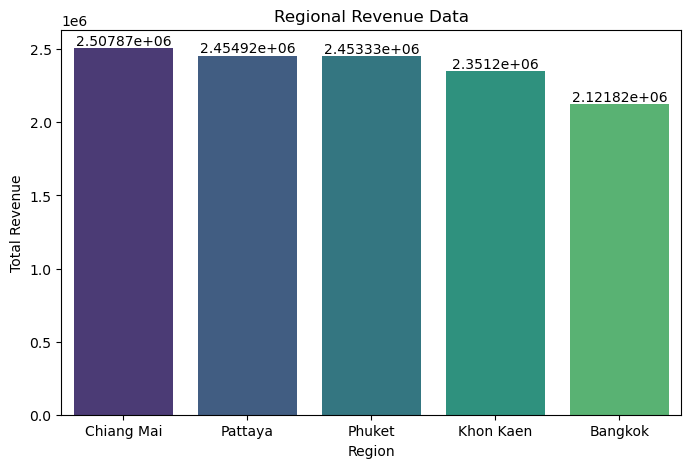

In [34]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=region_revenue,x='region',y='total_revenue')
ax.bar_label(ax.containers[0])
plt.title('Regional Revenue Data')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.show()

In [35]:
regional_orders =  df['region'].value_counts().reset_index()
regional_orders.columns = ['region','order_no']
regional_orders

,region,order_no
0,Pattaya,1044
1,Khon Kaen,1024
2,Chiang Mai,991
3,Bangkok,983
4,Phuket,958


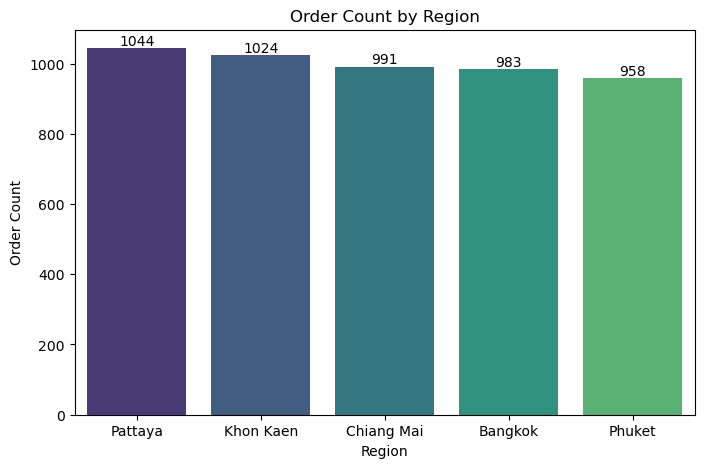

In [36]:
plt.figure(figsize=(8,5))
ax = sns.barplot(data=regional_orders,x='region',y='order_no')
ax.bar_label(ax.containers[0])
plt.xlabel('Region')
plt.title('Order Count by Region')
plt.ylabel('Order Count')
plt.show()

In [37]:
# Average vehicle type with shipping cost 
average_shipping_cost_by_vehicle_type = df.groupby('vehicle_type')['shipping_cost_per_unit'].mean().round(3).sort_values(ascending=False).reset_index()
average_shipping_cost_by_vehicle_type 

,vehicle_type,shipping_cost_per_unit
0,Van,21.028
1,Bike,20.951
2,Truck,19.755


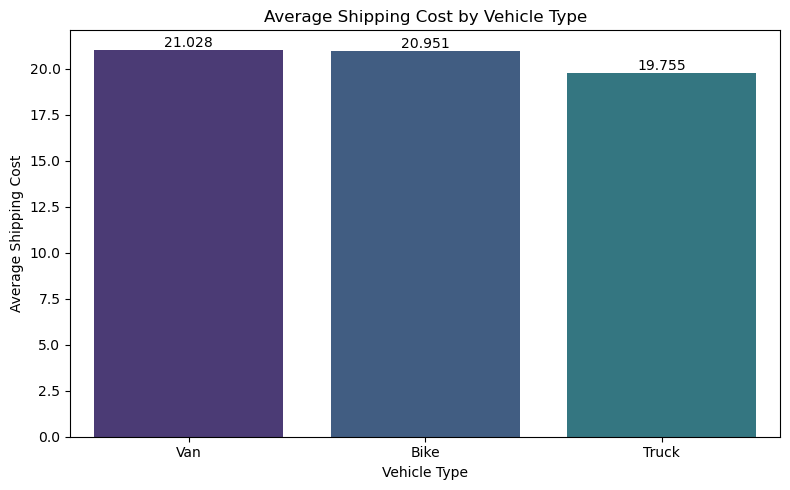

In [38]:
plt.figure(figsize=(8,5))
plt.title('Average Shipping Cost by Vehicle Type')
ax = sns.barplot(data=average_shipping_cost_by_vehicle_type,x='vehicle_type',y='shipping_cost_per_unit')
plt.xlabel('Vehicle Type')
ax.bar_label(ax.containers[0])
plt.ylabel('Average Shipping Cost')
plt.tight_layout()
plt.show()

In [39]:
#Which city has most orders?
city_orders = df.groupby('city')['order_id'].count().sort_values(ascending=False).reset_index()
city_orders.columns = ['city','total_orders']
city_orders['rank'] = city_orders['total_orders'].rank(method='dense',ascending=False)
city_orders

,city,total_orders,rank
0,Mueang,866,1.0
1,Jomtien,540,2.0
2,Central Pattaya,504,3.0
3,Ban Phai,492,4.0
4,Hang Dong,350,5.0
5,Patong,333,6.0
6,Rawai,332,7.0
7,San Sai,307,8.0
8,Kathu,293,9.0
9,Chatuchak,258,10.0


In [40]:
profits_by_vehicle_type = df.groupby('vehicle_type')['profit'].sum().sort_values(ascending=False).reset_index()
profits_by_vehicle_type['rank'] = profits_by_vehicle_type['profit'].rank(method='dense',ascending=False)
profits_by_vehicle_type

,vehicle_type,profit,rank
0,Truck,4165778.77,1.0
1,Van,4004886.27,2.0
2,Bike,3412896.11,3.0


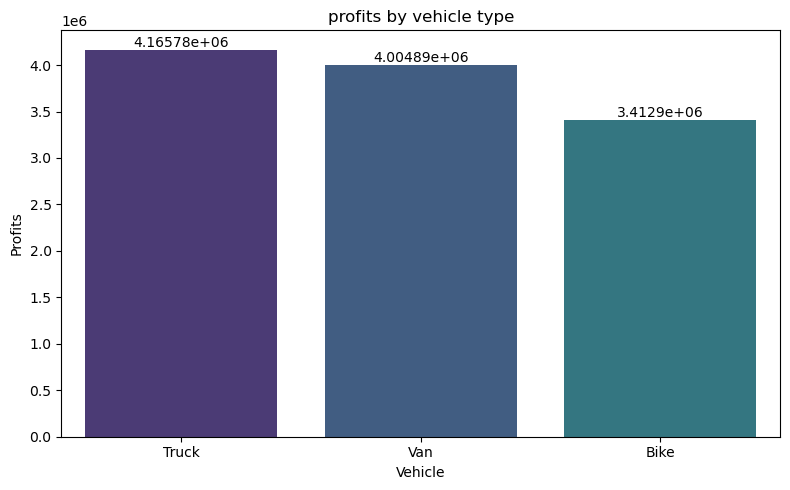

In [41]:
plt.figure(figsize=(8,5))
plt.title('profits by vehicle type')
ax  =sns.barplot(data=profits_by_vehicle_type,x='vehicle_type',y='profit')
plt.xlabel('Vehicle')
plt.ylabel('Profits')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [42]:
average_delivery_days_by_vehicle = df.groupby('vehicle_type')['delivery_days'].mean().sort_values(ascending=False).reset_index()
average_delivery_days_by_vehicle.columns = ['vehicle_type','average_delivery_days']
average_delivery_days_by_vehicle['rank'] = average_delivery_days_by_vehicle['average_delivery_days'].rank(method='dense',ascending=False)
average_delivery_days_by_vehicle

,vehicle_type,average_delivery_days,rank
0,Truck,6.119926,1.0
1,Bike,6.092514,2.0
2,Van,6.043328,3.0


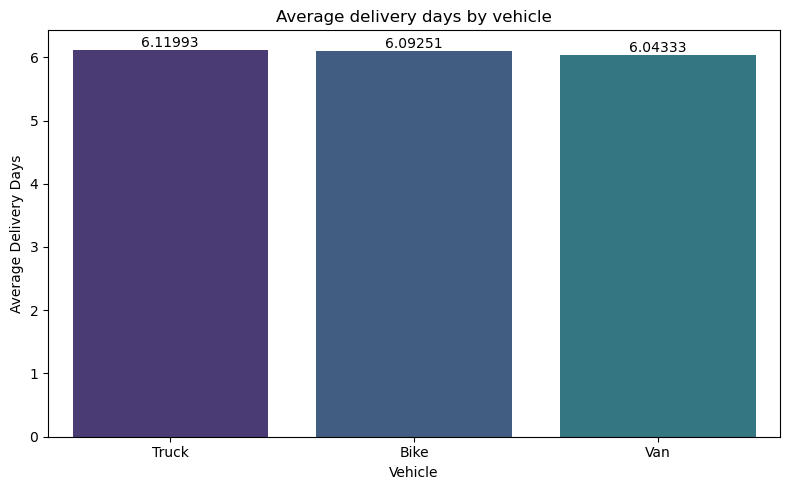

In [43]:
plt.figure(figsize=(8,5))
plt.title('Average delivery days by vehicle')
ax = sns.barplot(data=average_delivery_days_by_vehicle,x='vehicle_type',y='average_delivery_days')
plt.xlabel('Vehicle')
plt.ylabel('Average Delivery Days')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [44]:
monthly_revenue = df.groupby('order_month')['revenue'].sum().sort_values().reset_index()
monthly_revenue

,order_month,revenue
0,May,11889144.48


In [45]:
# Top 10 Customers by revenue 
customer_spent = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).reset_index()
customer_spent.columns = ['customer_id','total_spent']
customer_spent['rank'] = customer_spent['total_spent'].rank(method='dense',ascending=False)
customer_spent


,customer_id,total_spent,rank
0,CUST1412,239049.60,1.0
1,CUST2570,135935.58,2.0
2,CUST1475,133872.15,3.0
3,CUST2715,126629.99,4.0
4,CUST1718,124258.67,5.0
...,...,...,...
1843,CUST1549,42.42,1843.0
1844,CUST1027,29.94,1844.0
1845,CUST2785,26.50,1845.0
1846,CUST2468,26.06,1846.0


In [46]:
top_10_customers = customer_spent.head(10)
top_10_customers

,customer_id,total_spent,rank
0,CUST1412,239049.60,1.0
1,CUST2570,135935.58,2.0
2,CUST1475,133872.15,3.0
3,CUST2715,126629.99,4.0
4,CUST1718,124258.67,5.0
5,CUST1701,120344.66,6.0
6,CUST2149,120266.68,7.0
7,CUST1755,119552.94,8.0
8,CUST1115,116950.08,9.0
9,CUST2615,89862.19,10.0


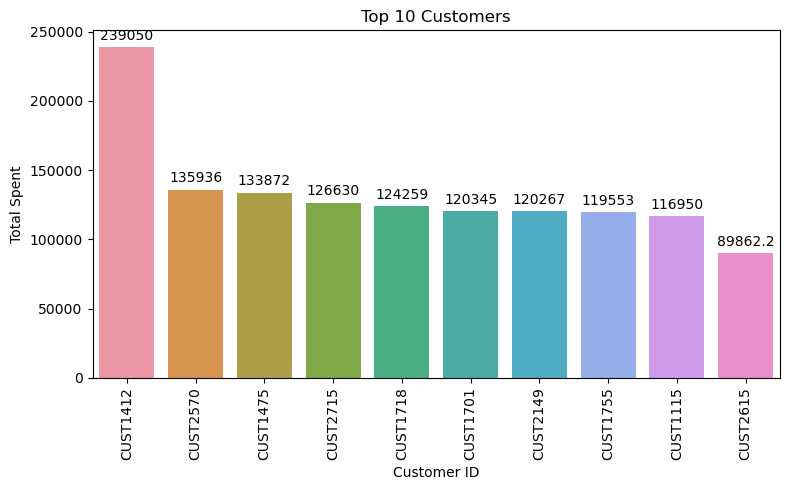

In [47]:
plt.figure(figsize=(8,5))
plt.title('Top 10 Customers')
ax = sns.barplot(data=top_10_customers,x='customer_id',y='total_spent')
plt.xlabel('Customer ID')
ax.bar_label(ax.containers[0],padding=3,fontsize=10)
plt.ylabel('Total Spent')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [48]:
status_revenue = df.groupby('status')['revenue'].sum().sort_values(ascending=False).reset_index()
status_revenue

,status,revenue
0,Completed,7279025.15
1,Cancelled,2391413.18
2,Delayed,2218706.15


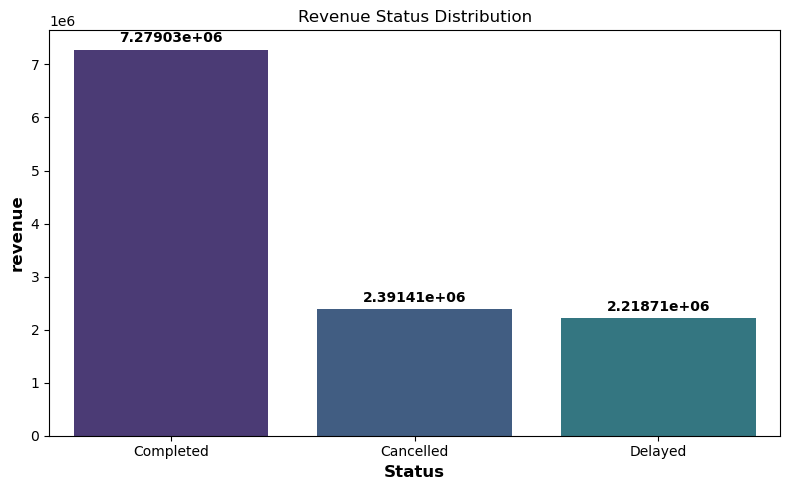

In [49]:
# Revenue Status Distribution 
plt.figure(figsize=(8,5))
plt.title('Revenue Status Distribution')
ax = sns.barplot(data=status_revenue,x='status',y='revenue')
ax.bar_label(ax.containers[0],padding= 3,fontweight='bold')
plt.xlabel('Status',fontsize=12,fontweight='bold')
plt.ylabel('revenue',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()

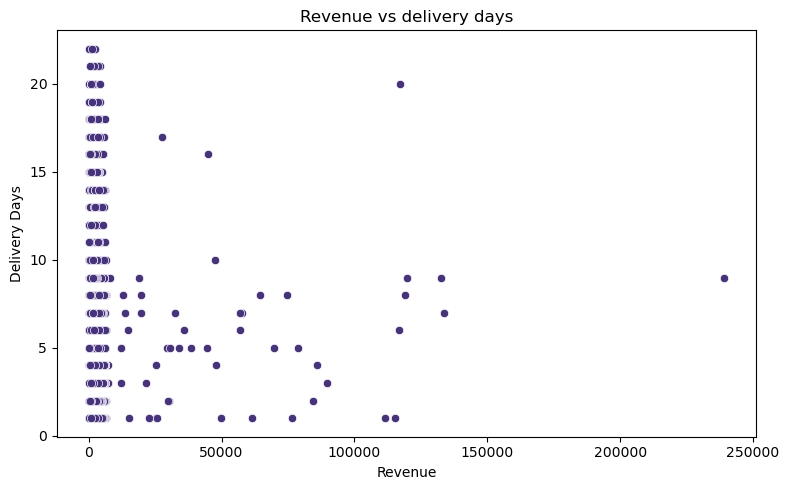

In [50]:
# Revenue vs delivery days scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='revenue',y='delivery_days')
plt.title('Revenue vs delivery days')
plt.xlabel('Revenue')
plt.ylabel('Delivery Days')
plt.tight_layout()
plt.show()

## Outliers Detection of revenue

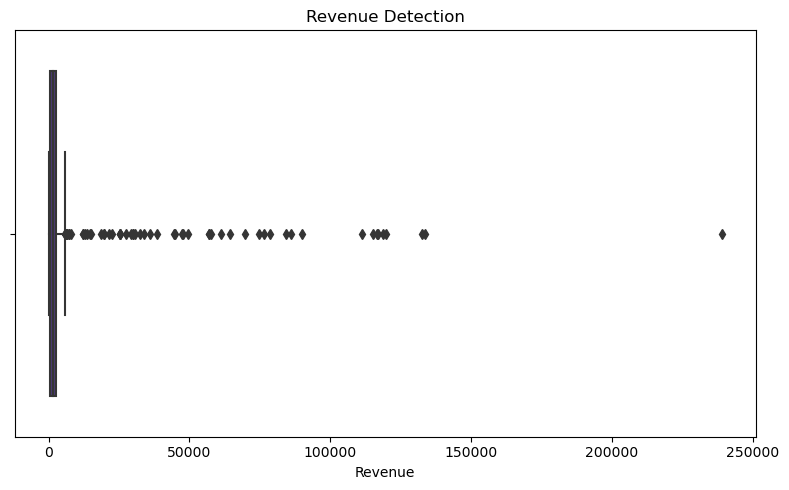

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='revenue')
plt.title('Revenue Detection')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

Check the revenue outliers by type

In [52]:
df['revenue_outlier'].value_counts()

False    4905
True       95
Name: revenue_outlier, dtype: int64

In [53]:
df[df['revenue_outlier'] == True]

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,...,shipping_cost,status,revenue_check,revenue_outlier,delivery_days_outlier,order_month,order_year,profit,shipping_cost_per_unit,delivery_speed
11,ORD00012,CUST2990,AG129,Pattaya,Jomtien,2026-05-09,2026-05-15,6,Bike,7,...,105.35,Completed,944.58,True,False,May,2026,35788.69,15.050000,Slow
126,ORD00127,CUST1763,AG073,Bangkok,Sukhumvit,2026-05-09,2026-05-10,1,Van,8,...,73.96,Completed,6343.04,True,False,May,2026,6269.08,9.245000,Fast
140,ORD00141,CUST1383,AG171,Pattaya,Central Pattaya,2026-05-09,2026-05-18,9,Truck,3,...,30.39,Delayed,720.30,True,False,May,2026,18697.41,10.130000,Slow
153,ORD00154,CUST2367,AG089,Bangkok,Bang Kapi,2026-05-09,2026-05-12,3,Truck,8,...,116.17,Completed,6382.72,True,False,May,2026,6266.55,14.521250,Normal
166,ORD00167,CUST2489,AG094,Bangkok,Lat Krabang,2026-05-09,2026-05-14,5,Van,8,...,52.85,Completed,1885.92,True,False,May,2026,33893.71,6.606250,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4735,ORD04736,CUST2017,AG129,Phuket,Kathu,2026-05-09,2026-05-15,6,Truck,5,...,27.89,Cancelled,3798.55,True,False,May,2026,56950.36,5.578000,Slow
4838,ORD04839,CUST2308,AG200,Phuket,Kathu,2026-05-09,2026-05-15,6,Bike,8,...,88.09,Delayed,6191.60,True,False,May,2026,6103.51,11.011250,Slow
4886,ORD04887,CUST1266,AG152,Pattaya,Jomtien,2026-05-09,2026-05-16,7,Van,3,...,86.28,Completed,612.69,True,False,May,2026,19519.80,28.760000,Slow
4903,ORD04904,CUST2728,AG137,Pattaya,Jomtien,2026-05-09,2026-05-17,8,Bike,8,...,102.74,Completed,6136.64,True,False,May,2026,6033.90,12.842500,Slow


In [54]:
# Which vehicle type has most outliers?
df[df['revenue_outlier'] == True]['vehicle_type'].value_counts()

Van      33
Bike     31
Truck    31
Name: vehicle_type, dtype: int64

In [55]:
#Which region has most outlier order?
df[df['revenue_outlier'] == True]['region'].value_counts()

Pattaya       30
Khon Kaen     18
Chiang Mai    16
Phuket        16
Bangkok       15
Name: region, dtype: int64

In [56]:
# Are outliers mostly delayed?
df[df['revenue_outlier'] == True]['delivery_days'].mean()

5.88421052631579

In [57]:
# Are outliers mostly cancelled or completed?
df[df['revenue_outlier'] == True]['status'].value_counts()

Completed    60
Cancelled    23
Delayed      12
Name: status, dtype: int64

In [58]:
delivery_days_status = df.groupby('status')['delivery_days'].mean().sort_values(ascending=False).reset_index()
delivery_days_status

,status,delivery_days
0,Completed,6.110635
1,Cancelled,6.063147
2,Delayed,6.025075


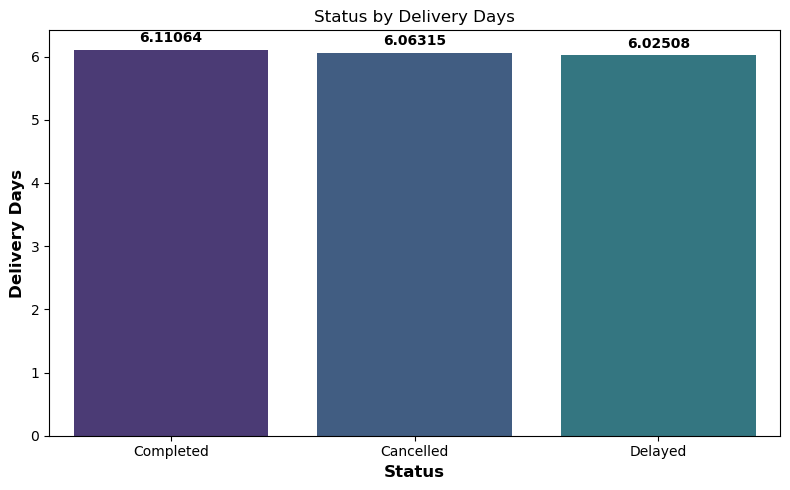

In [59]:
# Delivery Days Status Distribution 
plt.figure(figsize=(8,5))
ax = sns.barplot(data=delivery_days_status,x='status',y='delivery_days')
ax.bar_label(ax.containers[0],padding= 3,fontweight='bold')
plt.title('Status by Delivery Days')
plt.xlabel('Status',fontsize=12,fontweight='bold')
plt.ylabel('Delivery Days',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()

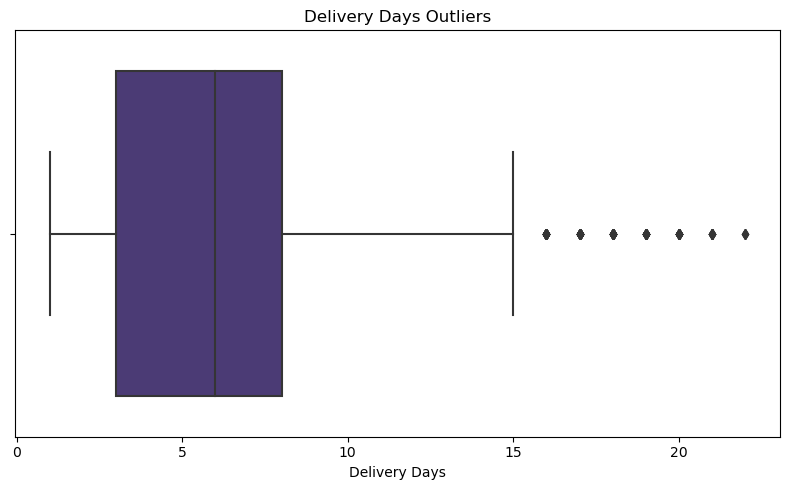

In [60]:
# Delivery Days Outliers Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x='delivery_days')
plt.title('Delivery Days Outliers')
plt.xlabel('Delivery Days')
plt.tight_layout()
plt.show()

In [61]:
# Delivery Days Outliers Detection
df[df['delivery_days_outlier']== True]

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,...,shipping_cost,status,revenue_check,revenue_outlier,delivery_days_outlier,order_month,order_year,profit,shipping_cost_per_unit,delivery_speed
37,ORD00038,CUST1633,AG171,Chiang Mai,Hang Dong,2026-05-09,2026-05-26,17,Van,6,...,108.21,Cancelled,3204.48,False,True,May,2026,3096.27,18.035000,Slow
49,ORD00050,CUST1102,AG067,Chiang Mai,San Sai,2026-05-09,2026-05-29,20,Van,1,...,104.29,Completed,76.32,False,True,May,2026,-27.97,104.290000,Slow
55,ORD00056,CUST2301,AG213,Pattaya,Jomtien,2026-05-09,2026-05-25,16,Van,1,...,14.45,Completed,681.16,False,True,May,2026,666.71,14.450000,Slow
67,ORD00068,CUST1355,AG142,Phuket,Rawai,2026-05-09,2026-05-25,16,Bike,4,...,11.58,Completed,2016.64,False,True,May,2026,2005.06,2.895000,Slow
75,ORD00076,CUST1268,AG074,Pattaya,Jomtien,2026-05-09,2026-05-26,17,Van,8,...,26.02,Cancelled,4032.56,False,True,May,2026,4006.54,3.252500,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4898,ORD04899,CUST2067,AG198,Chiang Mai,San Sai,2026-05-09,2026-05-25,16,Truck,1,...,78.57,Completed,711.02,False,True,May,2026,632.45,78.570000,Slow
4921,ORD04922,CUST2516,AG049,Pattaya,Jomtien,2026-05-09,2026-05-29,20,Bike,2,...,80.96,Cancelled,816.28,False,True,May,2026,735.32,40.480000,Slow
4957,ORD04958,CUST2716,AG105,Pattaya,Jomtien,2026-05-09,2026-05-30,21,Bike,7,...,77.40,Delayed,1811.53,False,True,May,2026,1734.13,11.057143,Slow
4967,ORD04968,CUST2671,AG107,Pattaya,Central Pattaya,2026-05-09,2026-05-30,21,Bike,1,...,25.42,Completed,463.20,False,True,May,2026,437.78,25.420000,Slow


In [62]:
#Which region has most delivery outliers?
df[df['delivery_days_outlier']==True]['region'].value_counts()

Chiang Mai    34
Pattaya       31
Bangkok       30
Khon Kaen     28
Phuket        19
Name: region, dtype: int64

In [63]:
#Which vehicle type causes delays most?
df[df['delivery_days_outlier']==True]['vehicle_type'].value_counts()

Bike     55
Van      44
Truck    43
Name: vehicle_type, dtype: int64

In [64]:
# Are delayed outliers mostly cancelled?
df[df['delivery_days_outlier']==True]['status'].value_counts()

Completed    87
Cancelled    34
Delayed      21
Name: status, dtype: int64

In [65]:
df[df['delivery_days_outlier']==True]['delivery_days'].mean()

17.964788732394368

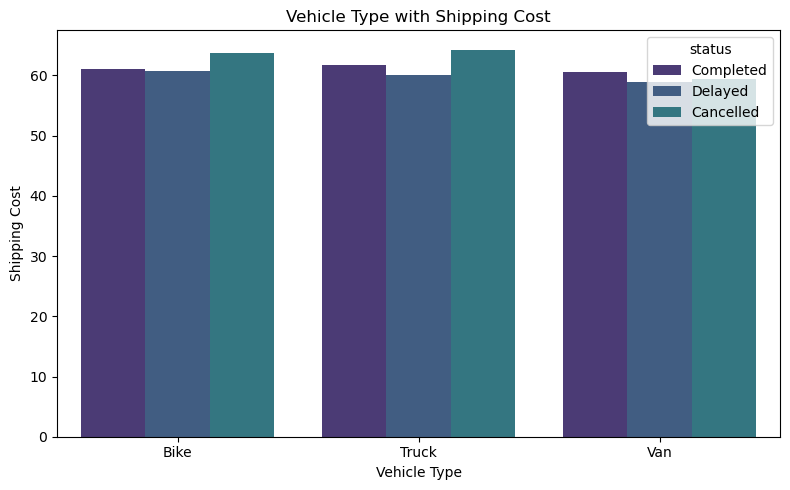

In [66]:
#Vehicle Type with Shipping Cost
plt.figure(figsize=(8,5))
plt.title('Vehicle Type with Shipping Cost')
ax = sns.barplot(data=df, x='vehicle_type', y='shipping_cost',hue='status', ci=None)
# Label each bar
plt.xlabel('Vehicle Type')
plt.ylabel('Shipping Cost')
#ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


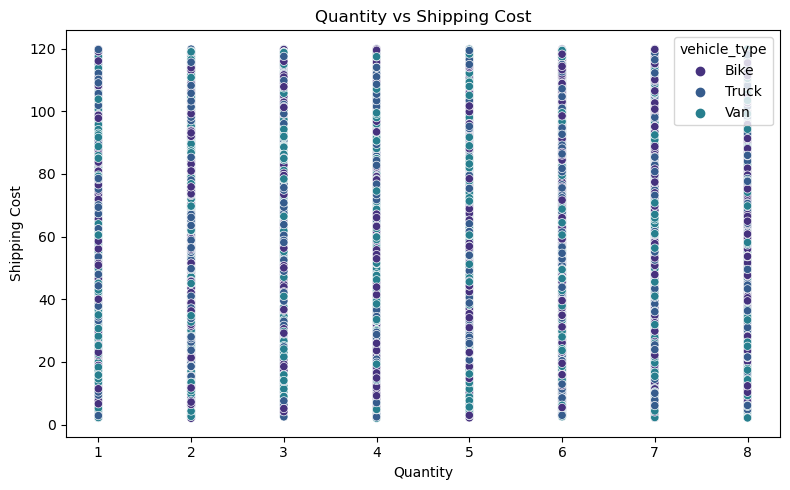

In [67]:
# Relationship between Quantity and Shipping Cost
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x='quantity',y='shipping_cost',hue='vehicle_type')
plt.xlabel('Quantity')
plt.ylabel('Shipping Cost')
plt.title('Quantity vs Shipping Cost')
plt.tight_layout()
plt.show()

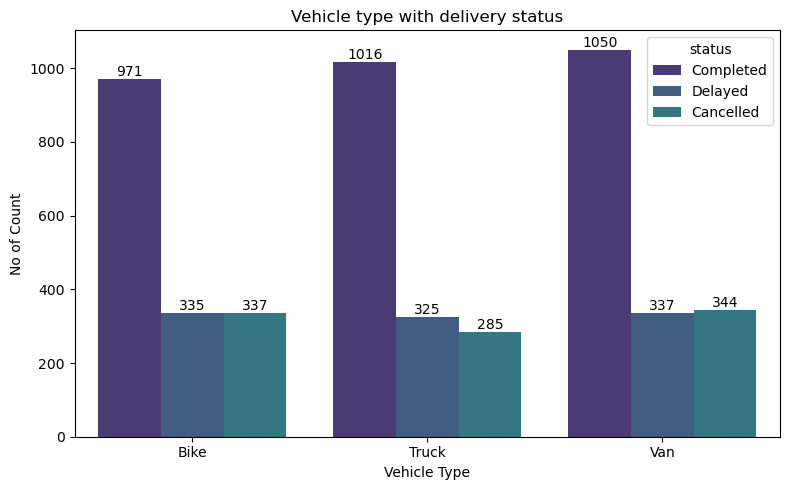

In [68]:
# Vehicle Type with delivery status 
plt.figure(figsize=(8,5))
plt.title('Vehicle type with delivery status')
ax = sns.countplot(data=df,x='vehicle_type',hue='status')
for container in ax.containers:
    ax.bar_label(container)
plt.xlabel('Vehicle Type')
plt.ylabel('No of Count')
plt.tight_layout()
plt.show()

In [69]:
# Cancelled Order analysis 
cancelled = df[df['status']=='Cancelled']
cancelled

,order_id,customer_id,agent_id,region,city,order_date,delivery_date,delivery_days,vehicle_type,quantity,...,shipping_cost,status,revenue_check,revenue_outlier,delivery_days_outlier,order_month,order_year,profit,shipping_cost_per_unit,delivery_speed
12,ORD00013,CUST2881,AG001,Pattaya,Central Pattaya,2026-05-09,2026-05-14,5,Truck,4,...,65.65,Cancelled,522.96,False,False,May,2026,457.31,16.412500,Normal
15,ORD00016,CUST1924,AG031,Chiang Mai,San Sai,2026-05-09,2026-05-13,4,Bike,7,...,53.70,Cancelled,5573.19,False,False,May,2026,5519.49,7.671429,Normal
17,ORD00018,CUST1968,AG063,Bangkok,Sukhumvit,2026-05-09,2026-05-14,5,Van,4,...,106.12,Cancelled,1743.96,False,False,May,2026,1637.84,26.530000,Normal
22,ORD00023,CUST2506,AG139,Phuket,Kathu,2026-05-09,2026-05-18,9,Bike,8,...,116.31,Cancelled,1058.32,False,False,May,2026,942.01,14.538750,Slow
24,ORD00025,CUST2157,AG134,Chiang Mai,Hang Dong,2026-05-09,2026-05-11,2,Van,4,...,11.67,Cancelled,1869.40,False,False,May,2026,1857.73,2.917500,Fast
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4955,ORD04956,CUST2477,AG104,Khon Kaen,Mueang,2026-05-09,2026-05-12,3,Van,7,...,40.99,Cancelled,1227.10,False,False,May,2026,1186.11,5.855714,Normal
4956,ORD04957,CUST1256,AG161,Bangkok,Chatuchak,2026-05-09,2026-05-13,4,Truck,2,...,103.32,Cancelled,483.06,False,False,May,2026,379.74,51.660000,Normal
4968,ORD04969,CUST2023,AG046,Khon Kaen,Ban Phai,2026-05-09,2026-05-16,7,Van,6,...,68.81,Cancelled,2439.66,False,False,May,2026,2370.85,11.468333,Slow
4989,ORD04990,CUST1062,AG075,Chiang Mai,Mueang,2026-05-09,2026-05-18,9,Van,6,...,64.44,Cancelled,1877.70,False,False,May,2026,1813.26,10.740000,Slow


In [70]:
cancelled.to_csv('cancelled_orders.csv',index=False)

In [71]:
# Cancellation Rate by Region 
cancel_rate_by_region =df.groupby('region')['status'].apply(lambda x: (x=="Cancelled").sum()/len(x)*100).sort_values(ascending=False).reset_index()
cancel_rate_by_region.columns = ['region','cancellation_rate%']
cancel_rate_by_region

,region,cancellation_rate%
0,Chiang Mai,20.181635
1,Khon Kaen,19.921875
2,Bangkok,19.735504
3,Pattaya,18.582375
4,Phuket,18.162839


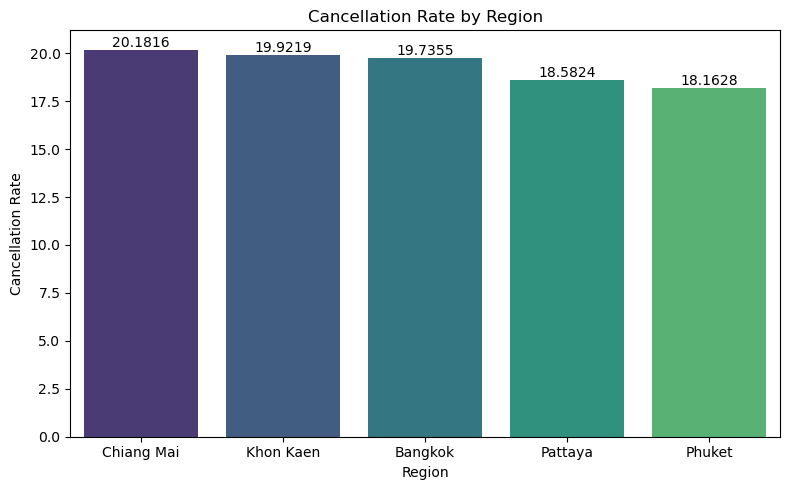

In [72]:
plt.figure(figsize=(8,5))
plt.title('Cancellation Rate by Region')

ax = sns.barplot(data=cancel_rate_by_region,y='cancellation_rate%',x='region')
ax.bar_label(ax.containers[0])
plt.xlabel('Region')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

In [73]:
cancel_by_vehicle_type =df.groupby('vehicle_type')['status'].apply(lambda x: (x=="Cancelled").sum()/len(x)*100).sort_values(ascending=False).reset_index()
cancel_by_vehicle_type.columns = ['vehicle_type','cancellation_rate%']
cancel_by_vehicle_type

,vehicle_type,cancellation_rate%
0,Bike,20.511260
1,Van,19.872906
2,Truck,17.527675


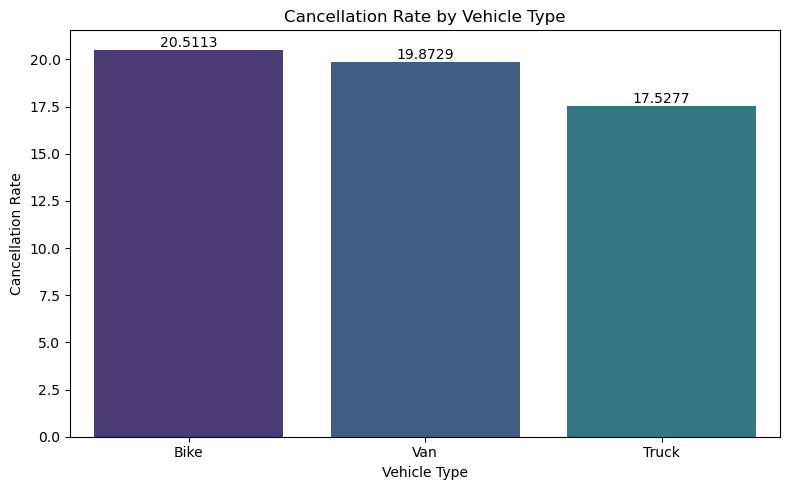

In [74]:
plt.figure(figsize=(8,5))
plt.title('Cancellation Rate by Vehicle Type')
ax = sns.barplot(data=cancel_by_vehicle_type,y='cancellation_rate%',x='vehicle_type')
ax.bar_label(ax.containers[0])
plt.xlabel('Vehicle Type')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

In [75]:
cancel_rate_speed = df.groupby('delivery_speed')['status'].apply(lambda x: (x=="Cancelled").sum()/len(x)*100).sort_values(ascending=False).reset_index()
cancel_rate_speed.columns = ['delivery_speed','cancellation_rate_%']
cancel_rate_speed

,delivery_speed,cancellation_rate_%
0,Normal,20.408163
1,Fast,19.589744
2,Slow,18.625192


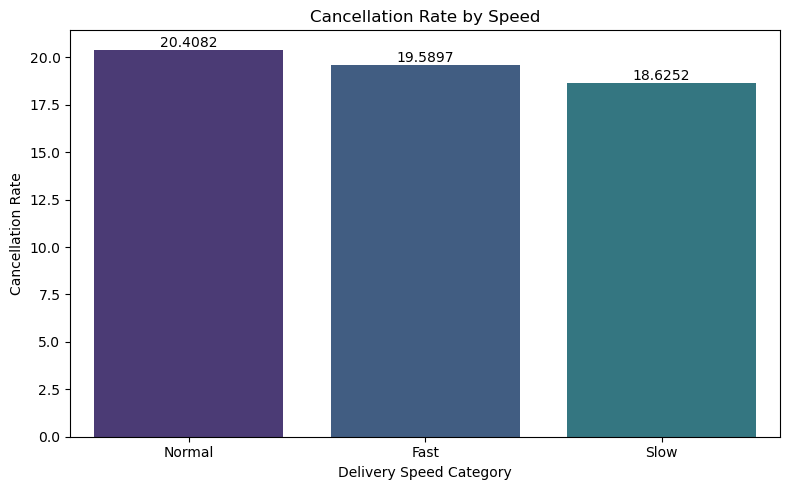

In [76]:
plt.figure(figsize=(8,5))
plt.title('Cancellation Rate by Speed')
ax = sns.barplot(data=cancel_rate_speed,y='cancellation_rate_%',x='delivery_speed')
ax.bar_label(ax.containers[0])
plt.xlabel('Delivery Speed Category')
plt.ylabel('Cancellation Rate')
plt.tight_layout()
plt.show()

In [77]:
comparison = df.groupby('status')[['delivery_days','quantity','unit_price','shipping_cost']].mean().round(2)
comparison

,delivery_days,quantity,unit_price,shipping_cost
status,,,,
Cancelled,6.06,4.56,414.43,62.38
Completed,6.11,4.48,400.14,61.12
Delayed,6.03,4.60,416.55,59.89


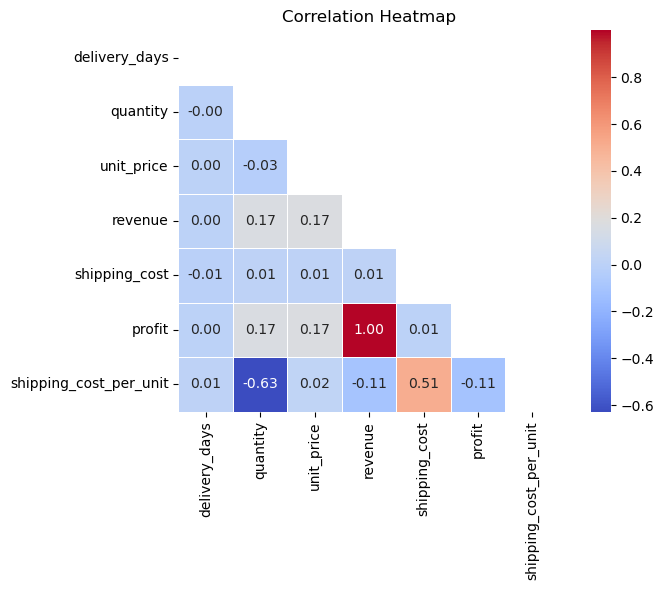

In [78]:
# Correlation 
# Keep only numeric columns
heatmap_columns = ['delivery_days','quantity','unit_price','revenue','shipping_cost','profit','shipping_cost_per_unit']
# Correlation matrix
corr = df[heatmap_columns].corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
plt.figure(figsize=(8,6))
sns.heatmap(corr,mask=mask
            ,annot=True,
            cmap='coolwarm',
           fmt='.2f',
           linewidths=0.5,
           square = True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [79]:
df.drop(columns=['revenue_check'],inplace= True)
df.to_csv('logistic_clean.csv',index=False)
print(f"Exported:{df.shape[0]} rows, {df.shape[1]} columns")

Exported:5000 rows, 21 columns


#### Key Findings 
- In Regional Revenue , Chiang Mai has the highest revenue.
- In Cancellation Rate by Region record, Chiang Mai has the highest cancellation rate with 20.182% .
- In average delivery days by vehicle, Truck takes the most average delivery days.
- In Speed vs Cancellation Rate record, Normal delivery orders have higher cancellation rate compared to the others.
- In top 10 customers data ,Cust1412 spent the most 239049.60 of the total revenue.
- Revenue Mismatch data, 57 rows  found with quantity * unit_price discrepancy.

